## Punganur Tomato Price Intelligence System
Using Agmarknet Mandi Data



In [2]:
import os
os.getcwd()


'C:\\Users\\DELL\\Tomato_Project'

In [3]:
import os
os.listdir()



['.ipynb_checkpoints',
 'Daily Price Report-25-12-2024 to 25-12-2025 for Andhra Pradesh.csv',
 'Untitled.ipynb']

## Load Raw Mandi Data


In [2]:
import pandas as pd
df_raw = pd.read_csv("Daily Price Report-25-12-2024 to 25-12-2025 for Andhra Pradesh.csv")

df = df_raw.copy()
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Daily Price Report-25-12-2024 to 25-12-2025 for Andhra Pradesh,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
1,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,000.00","4,000.00","3,000.00",Rs./Quintal,24-12-2025
2,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,400.00","4,400.00","3,400.00",Rs./Quintal,23-12-2025
3,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,840.00","4,340.00","3,340.00",Rs./Quintal,22-12-2025
4,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,800.00","4,800.00","3,800.00",Rs./Quintal,21-12-2025


## Fix Column Names



In [3]:
df.columns = df.iloc[0]
df = df.drop(0)
df = df.reset_index(drop=True)
df.head()

,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,000.00","4,000.00","3,000.00",Rs./Quintal,24-12-2025
1,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,400.00","4,400.00","3,400.00",Rs./Quintal,23-12-2025
2,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,840.00","4,340.00","3,340.00",Rs./Quintal,22-12-2025
3,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"2,800.00","4,800.00","3,800.00",Rs./Quintal,21-12-2025
4,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,"3,740.00","4,670.00","4,270.00",Rs./Quintal,20-12-2025


## Convert Price Columns to Numeric


In [4]:
price_cols = ["Min Price", "Max Price", "Modal Price"]

for col in price_cols:
    df[col] = df[col].str.replace(",", "").astype(float)
df.head()

,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2000.0,4000.0,3000.0,Rs./Quintal,24-12-2025
1,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2400.0,4400.0,3400.0,Rs./Quintal,23-12-2025
2,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2840.0,4340.0,3340.0,Rs./Quintal,22-12-2025
3,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2800.0,4800.0,3800.0,Rs./Quintal,21-12-2025
4,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,3740.0,4670.0,4270.0,Rs./Quintal,20-12-2025


## Convert Price Date to Datetime


In [5]:
df["Price Date"] = pd.to_datetime(df["Price Date"], format="%d-%m-%Y")
df.head()

,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2000.0,4000.0,3000.0,Rs./Quintal,2025-12-24
1,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2400.0,4400.0,3400.0,Rs./Quintal,2025-12-23
2,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2840.0,4340.0,3340.0,Rs./Quintal,2025-12-22
3,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2800.0,4800.0,3800.0,Rs./Quintal,2025-12-21
4,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,3740.0,4670.0,4270.0,Rs./Quintal,2025-12-20


##Sort by date

In [6]:
df = df.sort_values("Price Date")
df.head()

,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
318,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,1270.0,1670.0,1470.0,Rs./Quintal,2024-12-25
317,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,1070.0,1470.0,1270.0,Rs./Quintal,2024-12-26
316,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,1340.0,2000.0,1670.0,Rs./Quintal,2024-12-27
315,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,1200.0,1870.0,1540.0,Rs./Quintal,2024-12-28
314,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,840.0,1000.0,900.0,Rs./Quintal,2024-12-30


# Phase 2 – Market Analysis & Insights
Understanding how tomato prices behave over time in Punganur


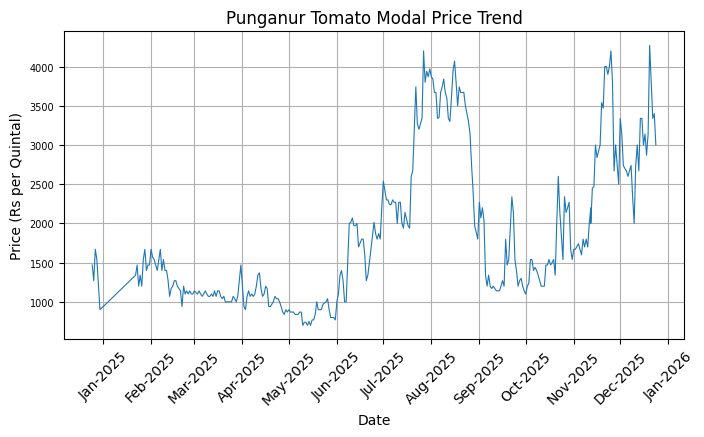

In [16]:
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

plt.figure(figsize=(8,4))
plt.plot(df["Price Date"], df["Modal Price"], linewidth=0.8)

plt.title("Punganur Tomato Modal Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (Rs per Quintal)")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(500))
plt.grid(True)

plt.xticks(rotation=45)
plt.yticks(fontsize=7)

plt.show()



## Monthly Price Trend
This section analyzes how average tomato prices change month by month to identify seasonal profit patterns.


In [27]:
df["Month"] = df["Price Date"].dt.to_period("M")
monthly_avg = df.groupby("Month")["Modal Price"].mean()
monthly_avg

Month
2024-12    1370.000000
2025-01    1410.000000
2025-02    1296.666667
2025-03    1093.000000
2025-04    1052.142857
2025-05     842.000000
2025-06    1648.769231
2025-07    2745.000000
2025-08    3419.285714
2025-09    1480.714286
2025-10    1620.357143
2025-11    2693.333333
2025-12    2999.583333
Freq: M, Name: Modal Price, dtype: float64

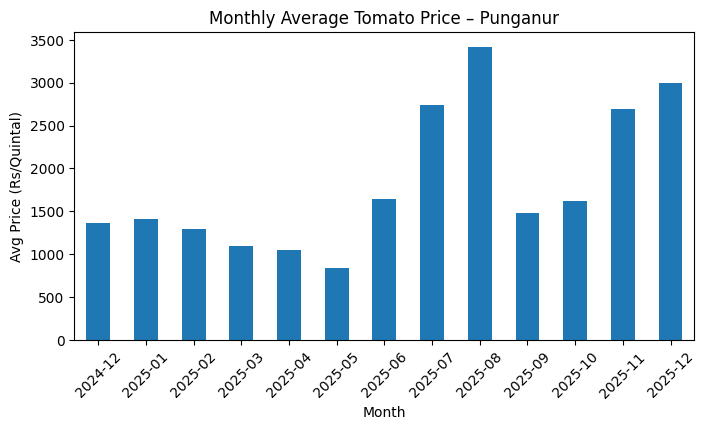

In [15]:
monthly_avg.plot(kind="bar", figsize=(8,4))
plt.title("Monthly Average Tomato Price – Punganur")
plt.xlabel("Month")
plt.ylabel("Avg Price (Rs/Quintal)")
plt.xticks(rotation=45)
plt.show()


## Price Volatility (Risk Analysis)
This section measures how unstable tomato prices are each month using standard deviation.
Higher volatility means higher risk.


In [17]:
monthly_volatility = df.groupby("Month")["Modal Price"].std()
monthly_volatility


Month
2024-12    299.916655
2025-01    146.590890
2025-02    201.627990
2025-03     92.704573
2025-04    134.063477
2025-05     90.378514
2025-06    374.131133
2025-07    744.727144
2025-08    557.925580
2025-09    401.966726
2025-10    397.943623
2025-11    894.784031
2025-12    473.933394
Freq: M, Name: Modal Price, dtype: float64

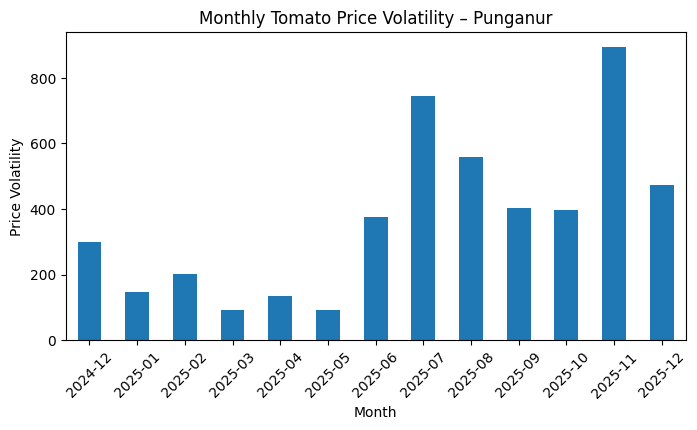

In [18]:
monthly_volatility.plot(kind="bar", figsize=(8,4))
plt.title("Monthly Tomato Price Volatility – Punganur")
plt.xlabel("Month")
plt.ylabel("Price Volatility")
plt.xticks(rotation=45)
plt.show()


## Profit vs Risk Decision Table
This table combines monthly average price (profit) and volatility (risk) to classify each month into
safe, risky, or high-profit market conditions.


In [19]:
monthly_avg = df.groupby("Month")["Modal Price"].mean()
monthly_volatility = df.groupby("Month")["Modal Price"].std()

decision_table = pd.DataFrame({
    "Avg Price": monthly_avg,
    "Volatility": monthly_volatility
})

decision_table


,Avg Price,Volatility
Month,,
2024-12,1370.000000,299.916655
2025-01,1410.000000,146.590890
2025-02,1296.666667,201.627990
2025-03,1093.000000,92.704573
2025-04,1052.142857,134.063477
2025-05,842.000000,90.378514
2025-06,1648.769231,374.131133
2025-07,2745.000000,744.727144
2025-08,3419.285714,557.925580


In [20]:
def classify(row):
    if row["Avg Price"] > 2500 and row["Volatility"] < 400:
        return "Best (High profit, low risk)"
    elif row["Avg Price"] > 2500 and row["Volatility"] >= 400:
        return "High profit, High risk"
    elif row["Avg Price"] <= 2500 and row["Volatility"] < 200:
        return "Low profit, Safe"
    else:
        return "Moderate"

decision_table["Market Type"] = decision_table.apply(classify, axis=1)
decision_table


,Avg Price,Volatility,Market Type
Month,,,
2024-12,1370.000000,299.916655,Moderate
2025-01,1410.000000,146.590890,"Low profit, Safe"
2025-02,1296.666667,201.627990,Moderate
2025-03,1093.000000,92.704573,"Low profit, Safe"
2025-04,1052.142857,134.063477,"Low profit, Safe"
2025-05,842.000000,90.378514,"Low profit, Safe"
2025-06,1648.769231,374.131133,Moderate
2025-07,2745.000000,744.727144,"High profit, High risk"
2025-08,3419.285714,557.925580,"High profit, High risk"


## Risk vs Profit Market Map
Each point represents one month.
This chart helps identify which months offer the best balance between profit and risk.


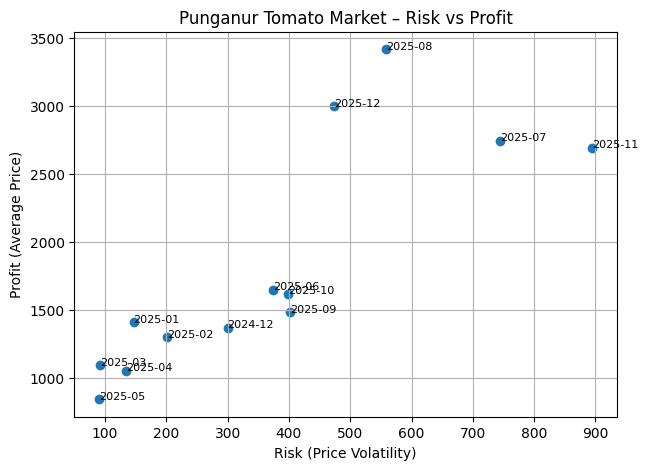

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(decision_table["Volatility"], decision_table["Avg Price"])

plt.xlabel("Risk (Price Volatility)")
plt.ylabel("Profit (Average Price)")
plt.title("Punganur Tomato Market – Risk vs Profit")

for month in decision_table.index:
    plt.text(decision_table.loc[month, "Volatility"],
             decision_table.loc[month, "Avg Price"],
             str(month), fontsize=8)

plt.grid(True)
plt.show()


## Power BI 

In [28]:
df.to_csv("clean_punganur_tomato_prices.csv", index=False)
df.tail()

,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date,Month
4,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,3740.0,4670.0,4270.0,Rs./Quintal,2025-12-20,2025-12
3,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2800.0,4800.0,3800.0,Rs./Quintal,2025-12-21,2025-12
2,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2840.0,4340.0,3340.0,Rs./Quintal,2025-12-22,2025-12
1,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2400.0,4400.0,3400.0,Rs./Quintal,2025-12-23,2025-12
0,Chittor,Punganur APMC,Vegetables,Tomato,Hybrid,FAQ,2000.0,4000.0,3000.0,Rs./Quintal,2025-12-24,2025-12


In [26]:
decision_table.to_csv("monthly_tomato_decision_table.csv")
decision_table.head()

,Avg Price,Volatility,Market Type
Month,,,
2024-12,1370.000000,299.916655,Moderate
2025-01,1410.000000,146.590890,"Low profit, Safe"
2025-02,1296.666667,201.627990,Moderate
2025-03,1093.000000,92.704573,"Low profit, Safe"
2025-04,1052.142857,134.063477,"Low profit, Safe"
